In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import linregress, t

from pneumococcus_data import data_observation

In [2]:
from sklearn.metrics import r2_score 

In [3]:
Iran, Denmark, Brazil, Nepal, Mozambique = data_observation()

In [4]:
country_strain = np.array([[np.array(Iran.strain), np.array(Denmark.strain)], [np.array(Brazil.strain), np.array(Mozambique.strain)]], dtype = object)
country_cases = np.array([[np.array(Iran.cases), np.array(Denmark.cases)], [np.array(Brazil.cases), np.array(Mozambique.cases)]], dtype = object)

Nepal_cases = np.array(Nepal.cases)
Nepal_strain = np.array(Nepal.strain)

slope, intercept, r, p, std_err, intercept_stderr
Nepal vs Iran: 0.4206247803828311| 0.5534056812349848| 0.4355623300244987| 0.0917295467585691| 0.2323269262543402
r_squared value: 0.1897145433363704
p-value intercept: 0.02877330523204815
------------------------------------------------------------------------------------
Nepal vs Denmark: 1.2123784955517853| -0.2192683600104819| 0.5984514568037469| 0.0007680813968371601| 0.31830347152606553
r_squared value: 0.3581441461505275
p-value intercept: 0.48833924666045203
------------------------------------------------------------------------------------
Nepal vs Brazil: 1.5471572837281342| -0.5543211465701134| 0.6811710700003215| 0.00034589593443299716| 0.3628719837335605
r_squared value: 0.4639940266053827
p-value intercept: 0.13342933894168957
------------------------------------------------------------------------------------
Nepal vs Mozambique: 0.6372705527733177| 0.3485247491845431| 0.4150874281684089| 0.008598659459562128| 0.22962571

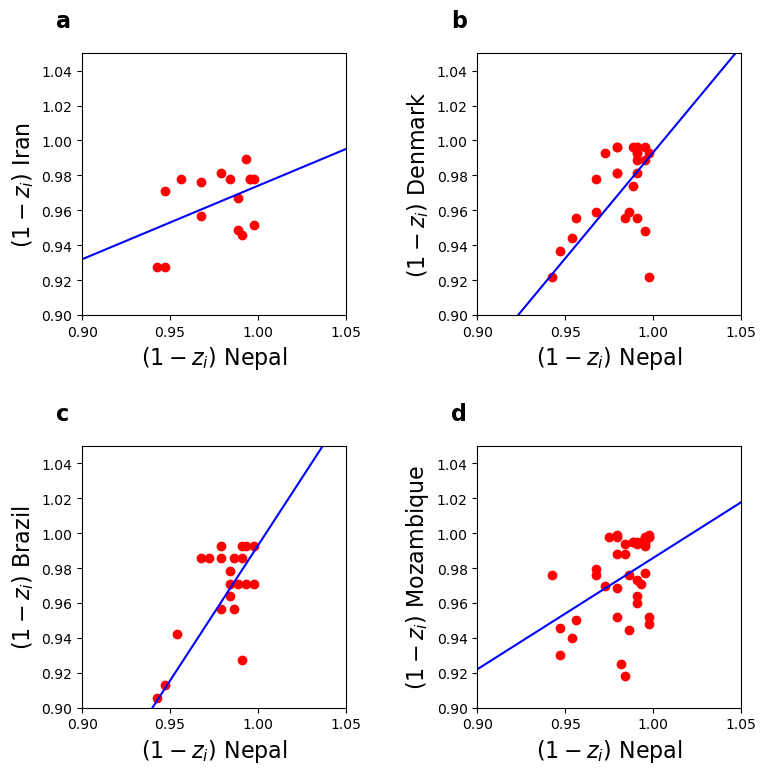

In [9]:
label = np.array([['Iran', 'Denmark'], ['Brazil', 'Mozambique']])
order = np.array([['a', 'b'], ['c', 'd']])

print('slope, intercept, r, p, std_err, intercept_stderr')

fig, ax = plt.subplots(2, 2, figsize = (8.5, 8.5))
fig.subplots_adjust(hspace = 0.5, wspace = 0.5)
x = np.linspace(0.9, 1.2, 80)


for i in range (0, 2):
    for j in range (0, 2):
        
        pair = [Nepal_strain, country_strain[i,j]]
        common_set = list(set.intersection(*map(set, pair)))
        
        Nepal_common = []
        second_common = []
        
        cases = country_cases[i,j]
        strains = country_strain[i,j]
        
        for strain in common_set:
            index_Nepal = np.where(Nepal_strain == strain) #find the index of common strain
            index_Nepal = index_Nepal[0]
            Nepal_common.extend(1 - Nepal_cases[index_Nepal])
            
            index_second = np.where(strains == strain) #find the index of common strain
            index_second = index_second[0]
            second_common.extend(1 - cases[index_second])
        
        Nepal_common = np.array(Nepal_common)
        second_common = np.array(second_common)
        slope, intercept, r, p, std_err = stats.linregress(Nepal_common, second_common)
        
        #test null hypothesis intercept
        yhat = intercept + slope * Nepal_common
        n = Nepal_common.size
        sse = np.sum((second_common - yhat)**2)
        s   = np.sqrt(sse / (n - 2))
        Sxx = np.sum((Nepal_common - Nepal_common.mean())**2)

        intercept_stderr = s * np.sqrt(1/n + (Nepal_common.mean()**2)/Sxx)
        #print("intercept_stderr =", intercept_stderr)
        
        df  = len(Nepal_common) - 2        # n - 2 d.f.
        t_stat = intercept /intercept_stderr
        p_intercept = 2 * t.sf(abs(t_stat), df)   # H0: intercept = 0
        #print("p-value intercept =", p_intercept)
        
        ax[i,j].scatter(Nepal_common, second_common, color = 'red')
        ax[i,j].plot(x, slope*x + intercept, color = 'blue')
        ax[i,j].set_xlim(0.9, 1.05)
        ax[i,j].set_ylim(0.9, 1.05)
        ax[i,j].set_xlabel('$(1-z_i)$ Nepal', fontsize = 16)
        ax[i,j].set_ylabel('$(1-z_i)$ {}'.format(label[i,j]), fontsize = 16)
        ax[i,j].text(-.1, 1.1, '{}'.format(order[i,j]), transform=ax[i,j].transAxes, size=16, weight='bold')
        
        print('Nepal vs {}: '.format(label[i,j])  +str(slope) + '| ' + str(intercept) + '| ' 
                                                  + str(r) + '| ' + str(p) + '| ' + str(std_err))
        
        model = Nepal_common*slope + intercept
        r_squared = r2_score(second_common, model)
        print( 'r_squared value: '+ str(r_squared))
        print( 'p-value intercept: '+ str(p_intercept))
        print('------------------------------------------------------------------------------------')
plt.show()

slope, intercept, r, p, std_err
Denmark vs Mozambique: 0.3878288707484717| 0.5975767121589876| 0.5699867079401992| 0.002933762616779415| 0.1165736561016694
r_squared value: 0.3248848472285055
p-value intercept: 2.23032967084747e-05
------------------------------------------------------------------------------------
Denmark vs Brazil: 0.5401970949053477| 0.43091709048819793| 0.5291296971376251| 0.035067124481909656| 0.23152553773351447
r_squared value: 0.2799782363929547
p-value intercept: 0.07305775225139073
------------------------------------------------------------------------------------
Mozambique vs Brazil: 0.46820383292761736| 0.5022045156975125| 0.2844084724264269| 0.21147593228239958| 0.3620760596262114
r_squared value: 0.08088817918793356
p-value intercept: 0.1686160532014133
------------------------------------------------------------------------------------


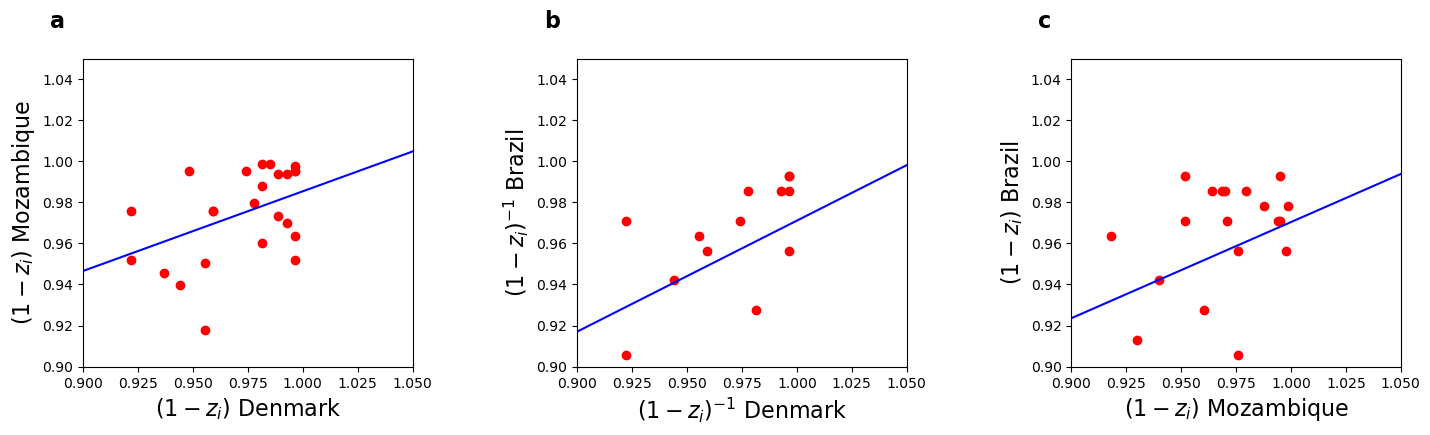

In [10]:
label = np.array(['Denmark', 'Brazil', 'Mozambique'])
order = np.array(['a', 'b', 'c'])
sub_country_strain = np.array([np.array(Denmark.strain), np.array(Brazil.strain), np.array(Mozambique.strain)], dtype = object)
sub_country_cases = np.array([np.array(Denmark.cases), np.array(Brazil.cases), np.array(Mozambique.cases)], dtype = object)


print('slope, intercept, r, p, std_err')

fig, ax = plt.subplots(1, 3, figsize = (17, 4))
fig.subplots_adjust( wspace = 0.5)
x = np.linspace(0.9, 1.2, 80)


for i in range (0, 3):
        ax[i].set_xlim(0.9, 1.05)
        ax[i].set_ylim(0.9, 1.05)
        
        s1_strain = sub_country_strain[i]
        s2_strain = sub_country_strain[i-1]
        
        s1_cases = sub_country_cases[i]
        s2_cases = sub_country_cases[i-1]
        
        pair = [s1_strain, s2_strain]
        common_set = list(set.intersection(*map(set, pair)))
        
        s1_common = []
        s2_common = []
                
        for strain in common_set:
            index_s1 = np.where(s1_strain == strain) #find the index of common strain
            index_s1 = index_s1[0]
            s1_common.extend(1 - s1_cases[index_s1])
            
            index_s2 = np.where(s2_strain == strain) #find the index of common strain
            index_s2 = index_s2[0]
            s2_common.extend(1 - s2_cases[index_s2])
        
        s1_common = np.array(s1_common)
        s2_common = np.array(s2_common)
        
        #swap the 2 axis in second figure
        if i == 1:
            temp = s1_common
            s1_common = s2_common
            s2_common = temp
            
        slope, intercept, r, p, std_err = stats.linregress(s1_common, s2_common)
        
        #test null hypothesis intercept
        yhat = intercept + slope * s1_common
        n = s1_common.size
        sse = np.sum((s2_common - yhat)**2)
        s   = np.sqrt(sse / (n - 2))
        Sxx = np.sum((s1_common - s1_common.mean())**2)

        intercept_stderr = s * np.sqrt(1/n + (s1_common.mean()**2)/Sxx)
        #print("intercept_stderr =", intercept_stderr)
        
        df  = len(s1_common) - 2        # n - 2 d.f.
        t_stat = intercept /intercept_stderr
        p_intercept = 2 * t.sf(abs(t_stat), df)   # H0: intercept = 0

        ax[i].scatter(s1_common, s2_common, color = 'red')
        ax[i].plot(x, slope*x + intercept, color = 'blue')
        if i == 1:
            ax[i].set_xlabel('$(1-z_i)^{{-1}}$ {}'.format(label[i-1]), fontsize = 16)
            ax[i].set_ylabel('$(1-z_i)^{{-1}}$ {}'.format(label[i]), fontsize = 16)
            ax[i].text(-.1, 1.1, '{}'.format(order[i]), transform=ax[i].transAxes, size=16, weight='bold')
        
            print('{} vs {}: '.format(label[i-1],label[i])  +str(slope) + '| ' + str(intercept) 
                                                            + '| ' + str(r) + '| ' + str(p) + '| ' + str(std_err))

        else:
            ax[i].set_xlabel('$(1-z_i)$ {}'.format(label[i]), fontsize = 16)
            ax[i].set_ylabel('$(1-z_i)$ {}'.format(label[i-1]), fontsize = 16)
            ax[i].text(-.1, 1.1, '{}'.format(order[i]), transform=ax[i].transAxes, size=16, weight='bold')
        
            print('{} vs {}: '.format(label[i],label[i-1])  +str(slope) + '| ' + str(intercept) 
                                                            + '| ' + str(r) + '| ' + str(p) + '| ' + str(std_err))
        
        model = s1_common*slope + intercept
        r_squared = r2_score(s2_common, model)
        print( 'r_squared value: '+ str(r_squared))
        print( 'p-value intercept: '+ str(p_intercept))
        print('------------------------------------------------------------------------------------')
        
plt.show()